# PSDCodec Demo Evaluation

This notebook is a thin graphical analysis of the generated `reports/benchmarks/demo_eval.json` artifact. It keeps the evaluation computation in `src/interfaces/evaluation.py` and uses the saved report only for visualization and interpretation.


## Notebook Flow

1. Load the saved demo evaluation report.
2. Display the key scalar metrics as a compact table.
3. Plot one four-panel overview covering distortion, rate, runtime, and model complexity.


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

if "interfaces.evaluation" in sys.modules:
    importlib.reload(sys.modules["interfaces.evaluation"])
evaluation = importlib.import_module("interfaces.evaluation")
build_demo_eval_summary_rows = evaluation.build_demo_eval_summary_rows
create_demo_eval_figure = evaluation.create_demo_eval_figure
load_demo_eval_report = evaluation.load_demo_eval_report

In [2]:
report_path = project_root / "reports" / "benchmarks" / "demo_eval.json"
if not report_path.exists():
    raise FileNotFoundError(
        "Expected reports/benchmarks/demo_eval.json. Run "
        "scripts/tools/demo_eval.py before opening this notebook."
    )

report = load_demo_eval_report(report_path)
display(
    Markdown(
        f"**Loaded report:** `{report_path}`\n\n"
        f"**Held-out validation PSD distortion:** "
        f"{report.validation_reference.psd_distortion_mean:.6f}\n\n"
        f"**Benchmark frames:** {report.dataset.total_frame_count}\n\n"
        f"**Runtime provider:** `{report.onnx_provider}`"
    )
)
report_path

**Loaded report:** `/home/marti/code/PSDCodec/reports/benchmarks/demo_eval.json`

**Held-out validation PSD distortion:** 0.012568

**Benchmark frames:** 64

**Runtime provider:** `CPUExecutionProvider`

PosixPath('/home/marti/code/PSDCodec/reports/benchmarks/demo_eval.json')

In [3]:
summary_frame = pd.DataFrame(build_demo_eval_summary_rows(report))
summary_frame

,section,metric,value,units
0,Validation,Held-out PSD distortion,1.256754e-02,D_psd
1,Validation,Held-out preprocessing distortion,2.141780e-02,D_psd
2,Validation,Held-out rate proxy,4.633078e+03,bits/frame
3,Benchmark,Benchmark PSD distortion,9.572486e-03,D_psd
4,Benchmark,Benchmark operational payload,4.619141e+03,bits/frame
5,Benchmark,Side-information share,1.524093e+01,%
6,Runtime,Encode latency,3.049749e+02,ms/frame
7,Runtime,Decode latency,1.763467e+02,ms/frame
8,Runtime,Exact round-trip fraction,1.000000e+00,fraction
9,Complexity,Total parameters,2.310690e+06,parameters


## Graphical Overview

The figure below separates the two evaluation boundaries on purpose: the validation reference comes from the exported training summary, while the deployment benchmark reflects the saved operational measurement subset.


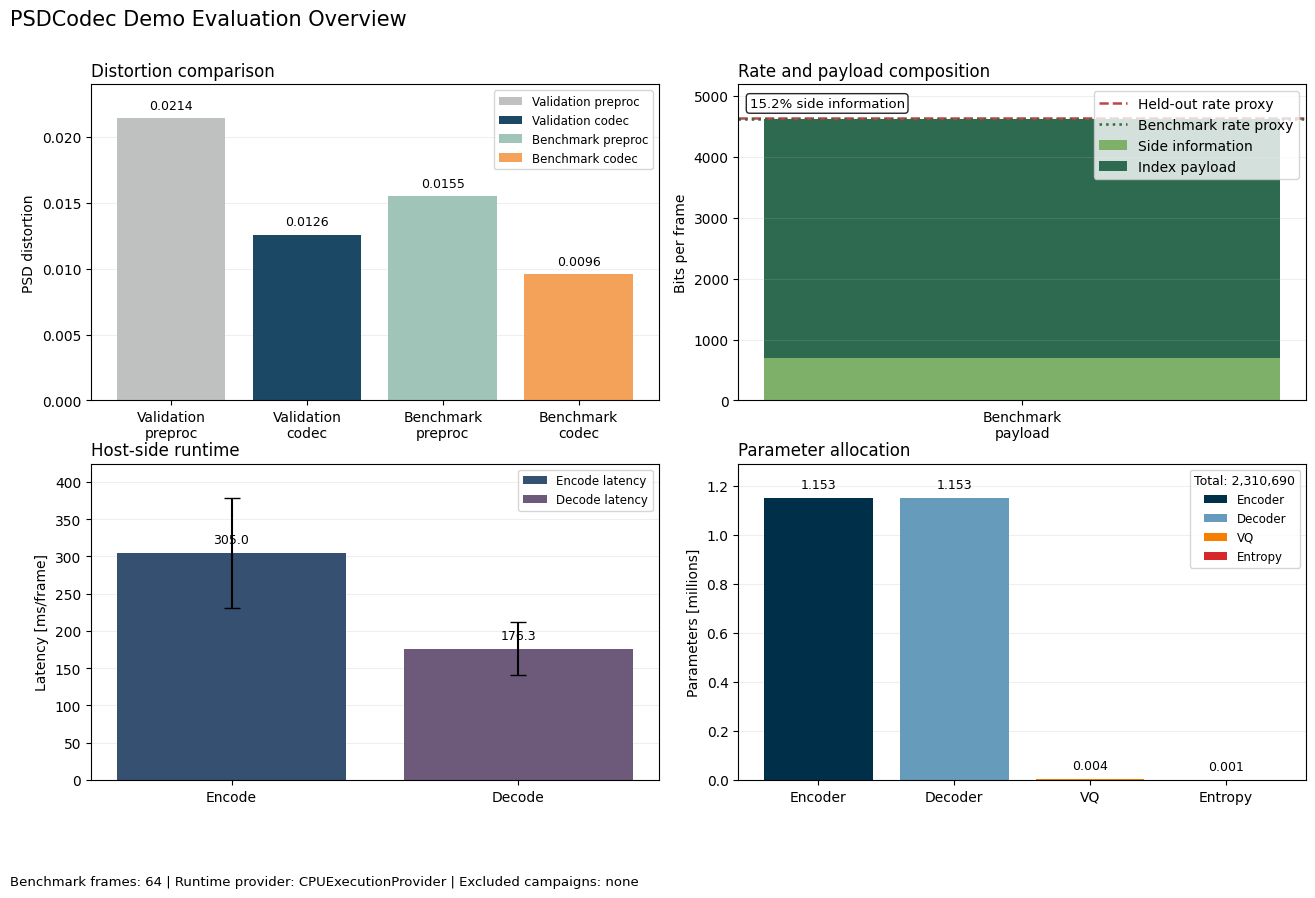

In [4]:
figure = create_demo_eval_figure(report)
plt.show()

## Reading The Figure

- **Distortion comparison** checks whether the deployment benchmark tracks the held-out validation behavior and whether the codec improves on the preprocessing-only baseline.
- **Rate and payload composition** shows how much of the operational payload is deterministic side information versus entropy-coded latent indices, with held-out and benchmark rate proxies overlaid as references.
- **Host-side runtime** reports the measured encode/decode latency on the current machine, so those numbers are deployment-host specific.
- **Parameter allocation** shows where the learned model capacity sits, which is useful when deciding whether future changes should target encoder width, decoder width, or codebook/entropy components.
